# Crosscoder Data Loading Inspection
This script shows how tokens are loaded from the HF dataset and processed for crosscoder training

## Setup

In [1]:
import os
import sys
import yaml
import torch
from pathlib import Path

# Patch for the Self type hint issue
# We'll monkey patch the typing module to add Self if it's not available
import typing
if not hasattr(typing, 'Self'):
    # Create a simple version of the Self type annotation
    typing.Self = typing.TypeVar('Self', bound=object)
    # Add it to the module's __all__ attribute to make it importable
    if hasattr(typing, '__all__'):
        typing.__all__ = list(typing.__all__) + ['Self']
    sys.modules['typing'] = typing

In [2]:
def find_repo_root(starting_path=None):
    """Find the root directory of the repository by looking for .git or specific files"""
    if starting_path is None:
        starting_path = Path.cwd()
    
    current_path = starting_path.absolute()
    
    # Try going up directories until we find repo indicators
    while current_path != current_path.parent:
        # Check for .git directory (common repo indicator)
        if (current_path / '.git').exists():
            return current_path
        
        # Check for specific files/directories that would indicate the repo root
        if (current_path / 'crosscode').exists() and \
           (current_path / 'pyproject.toml').exists() and \
           (current_path / 'README.md').exists():
            return current_path
            
        current_path = current_path.parent
    
    # If we get here, we didn't find a repo root
    raise FileNotFoundError(f"Could not find repository root from {starting_path}")

In [3]:
# ========== Set Up Paths ==========
# Find repository root
try:
    repo_root = find_repo_root()
    print(f"Repository root found at: {repo_root}")
except FileNotFoundError as e:
    print(f"Warning: {e}")
    print("Using current directory as base")
    repo_root = Path.cwd()

Repository root found at: /mnt/ssd-1/mechinterp/taras/crosscoder_training


In [4]:
# Set config path and cache directory
config_path = repo_root / "crosscode" / "trainers" / "topk_crosscoder" / "g_acausal_k120.yaml"
cache_dir = repo_root / "cache"
os.makedirs(cache_dir, exist_ok=True)

# Import the necessary modules from the codebase
print(f"Adding {repo_root} to Python path")
sys.path.insert(0, str(repo_root))

Adding /mnt/ssd-1/mechinterp/taras/crosscoder_training to Python path


In [5]:
# Import the necessary modules from the codebase
print(f"Adding {repo_root} to Python path")
sys.path.insert(0, str(repo_root))

Adding /mnt/ssd-1/mechinterp/taras/crosscoder_training to Python path


In [6]:
from crosscode.data.activations_dataloader import build_model_hookpoint_dataloader
from crosscode.llms import build_llms
from crosscode.log import logger
from crosscode.models import AnthropicTransposeInit, ModelHookpointAcausalCrosscoder, TopkActivation
from crosscode.models.activations.topk import BatchTopkActivation, GroupMaxActivation
from crosscode.trainers.base_trainer import run_exp
from crosscode.trainers.topk_crosscoder.config import TopKAcausalCrosscoderExperimentConfig
from crosscode.trainers.topk_crosscoder.trainer import TopKStyleAcausalCrosscoderTrainer
from crosscode.trainers.utils import build_wandb_run
from crosscode.utils import get_device
from crosscode.data.activation_harvester import ActivationsHarvester
from crosscode.data.token_loader import TokenSequenceLoader

## Loading the config

In [7]:
# ========== Load Configuration ==========
print(f"Loading configuration from: {config_path}")

# Load the configuration
with open(config_path) as f:
    config_dict = yaml.safe_load(f)

# Extract relevant data configuration
data_config = config_dict.get("data", {})
print(f"Dataset: {data_config['token_sequence_loader']['hf_dataset_name']}")
print(f"Sequence Length: {data_config['token_sequence_loader']['sequence_length']}")
print(f"Harvesting Batch Size: {data_config['activations_harvester']['harvesting_batch_size']}")

Loading configuration from: /mnt/ssd-1/mechinterp/taras/crosscoder_training/crosscode/trainers/topk_crosscoder/g_acausal_k120.yaml
Dataset: HuggingFaceFW/fineweb
Sequence Length: 256
Harvesting Batch Size: 8


In [8]:
cfg = TopKAcausalCrosscoderExperimentConfig(**config_dict)
cfg

TopKAcausalCrosscoderExperimentConfig(seed=10101, cache_dir='.cache', base_save_dir='.checkpoints', wandb=WandbConfig(entity='jnainani-university-of-massachusetts-amherst', project='acausal_cc_test2', mode='online'), experiment_name='k120_continuous_optimized_buffer', data=DataConfig(token_sequence_loader=HuggingfaceTextDatasetConfig(hf_dataset_name='HuggingFaceFW/fineweb', sequence_length=256, shuffle_buffer_size=None), activations_harvester=ActivationsHarvesterConfig(llms=[LLMConfig(name='google/gemma-2-2b', revision=None, base_archicteture_name=None, hf_model_name=None)], inference_dtype='float32', harvesting_batch_size=8, cache_mode='no_cache'), n_tokens_for_norm_estimate=100000), cuda_device=0, crosscoder=TopKCrosscoderConfig(n_latents=16384, use_encoder_bias=True, use_decoder_bias=True, dec_init_norm=0.01, k=120), train=TopKTrainConfig(batch_size=1024, optimizer=AdamConfig(type='adam', warmup_pct=0.005, learning_rate=0.0002, warmdown_pct=0.005, betas=(0.9, 0.999)), num_steps=3000

## Defining all the dataloading utilities

The code below is directly copied from `build_trainer` method in `crosscode/trainers/topk_crosscoder/run.py`

In [9]:
CUDA_DEVICE = 3
device = get_device(CUDA_DEVICE)

llms = build_llms(
	cfg.data.activations_harvester.llms,
	cfg.cache_dir,
	device,
	inferenced_type=cfg.data.activations_harvester.inference_dtype,
)

match cfg.train.topk_style:
	case "topk":
		cc_act = TopkActivation(k=cfg.crosscoder.k)
	case "batch_topk":
		cc_act = BatchTopkActivation(k_per_example=cfg.crosscoder.k)
	case "groupmax":
		cc_act = GroupMaxActivation(k_groups=cfg.crosscoder.k, latents_size=cfg.crosscoder.n_latents)

d_model = llms[0].cfg.d_model

crosscoder = ModelHookpointAcausalCrosscoder(
	n_models=len(llms),
	n_hookpoints=len(cfg.hookpoints),
	d_model=d_model,
	n_latents=cfg.crosscoder.n_latents,
	init_strategy=AnthropicTransposeInit(dec_init_norm=cfg.crosscoder.dec_init_norm),
	activation_fn=cc_act,
	use_encoder_bias=cfg.crosscoder.use_encoder_bias,
	use_decoder_bias=cfg.crosscoder.use_decoder_bias,
)
print('Load crosscoder to device')
crosscoder = crosscoder.to(device)

dataloader = build_model_hookpoint_dataloader(
	cfg=cfg.data,
	llms=llms,
	hookpoints=cfg.hookpoints,
	batch_size=cfg.train.minibatch_size(),
	cache_dir=cfg.cache_dir,
)

if cfg.train.k_aux is None:
	cfg.train.k_aux = d_model // 2
	print(f"defaulting to k_aux={cfg.train.k_aux} for crosscoder (({d_model}) // 2)")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


2025-04-27 17:35:17 - INFO - Assigned model key: tl-google_gemma-2-2b to model gemma-2-2b


Load crosscoder to device


Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

2025-04-27 17:35:37 - INFO - computed last needed layer: 21, stopping at 22


Estimating norm scaling factor: 100%|██████████| 391/391 [00:23<00:00, 16.36it/s]


## Analyzing Activation Norms by Sequence Position

Now, let's investigate the norms of the activations, specifically comparing tokens at position 1 (immediately after BOS) with other tokens in the sequence. We will intercept the data flow before the final filtering in the dataloader.

In [10]:
# Imports needed for this section
import torch
from einops import rearrange
import numpy as np
import pandas as pd
# Optional: for plotting
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOT_AVAILABLE = True
except ImportError:
    PLOT_AVAILABLE = False
    print("Matplotlib/Seaborn not found. Histograms will not be generated.")

In [24]:
# Configuration for the analysis
NUM_BATCHES_TO_ANALYZE = 100  # How many raw batches to process
TARGET_HOOKPOINTS = cfg.hookpoints # Analyze all hookpoints defined in the config
MODEL_INDEX = 0 # Assuming we analyze the first (or only) model

# Storage for norms
pos1_norms_per_hookpoint = {hp: [] for hp in TARGET_HOOKPOINTS}
other_norms_per_hookpoint = {hp: [] for hp in TARGET_HOOKPOINTS}
all_valid_norms_per_hookpoint = {hp: [] for hp in TARGET_HOOKPOINTS} # Includes pos1 and others
bos_norms_per_hookpoint = {hp: [] for hp in TARGET_HOOKPOINTS}

print(f"Analyzing {NUM_BATCHES_TO_ANALYZE} batches...")
print(f"Target Hookpoints: {TARGET_HOOKPOINTS}")
print(f"Model Index: {MODEL_INDEX}")

Analyzing 100 batches...
Target Hookpoints: ['blocks.12.hook_resid_post', 'blocks.13.hook_resid_post', 'blocks.14.hook_resid_post', 'blocks.15.hook_resid_post', 'blocks.16.hook_resid_post', 'blocks.17.hook_resid_post', 'blocks.18.hook_resid_post', 'blocks.19.hook_resid_post', 'blocks.20.hook_resid_post', 'blocks.21.hook_resid_post']
Model Index: 0


In [25]:
# Get the underlying components without modifying the main dataloader instance
token_sequence_loader = dataloader._token_sequence_loader
activations_harvester = dataloader._activations_harvester
scaling_factors_MP = dataloader.get_scaling_factors() # Shape (M, P)
scaling_factors_P = scaling_factors_MP[MODEL_INDEX].to(device) # Shape (P,) - for the target model

# Get a fresh iterator from the token loader
token_iter = token_sequence_loader.get_sequences_batch_iterator()

scaling_factors_P, scaling_factors_P.shape

(tensor([0.3246, 0.2756, 0.2607, 0.2337, 0.2029, 0.1938, 0.1702, 0.1545, 0.1377,
         0.1170], device='cuda:3'),
 torch.Size([10]))

In [26]:
# %%
# Process the specified number of batches
processed_batches = 0
while processed_batches < NUM_BATCHES_TO_ANALYZE:
	try:
		print(f"\nProcessing batch {processed_batches + 1}/{NUM_BATCHES_TO_ANALYZE}...")
		# 1. Get a batch of token sequences (includes BOS, special tokens)
		token_batch = next(token_iter)
		tokens_HS = token_batch.tokens_HS.to(device)
		special_tokens_mask_HS = token_batch.special_tokens_mask_HS.to(device)
		H, S = tokens_HS.shape
		print(f"  Token batch shape (H, S): ({H}, {S})")

		# 2. Get UNFILTERED activations for this batch
		# Shape: (H, S, M, P, D) - M=models, P=hookpoints, D=d_model
		activations_HSMPD = activations_harvester.get_activations_HSMPD(tokens_HS)
		print(f"  Raw activations shape (H, S, M, P, D): {activations_HSMPD.shape}")

		# Select the target model
		activations_HSPD = activations_HSMPD[:, :, MODEL_INDEX, :, :] # Shape: (H, S, P, D)

		# 3. Flatten H and S dimensions -> Hs...
		activations_HsPD = rearrange(activations_HSPD, "h s p d -> (h s) p d")
		special_tokens_mask_Hs = rearrange(special_tokens_mask_HS, "h s -> (h s)")

		# Create a position identifier for the flattened dimension
		positions_HS = torch.arange(S, device=device).repeat(H, 1) # Shape: (H, S)
		positions_Hs = rearrange(positions_HS, "h s -> (h s)") # Shape: (Hs,)

		# 4. Apply scaling factors (per hookpoint)
		# scaling_factors_P shape: (P,) -> reshape to (1, P, 1) for broadcasting
		scaled_activations_HsPD = activations_HsPD * scaling_factors_P.view(1, -1, 1)
		print(f"  Scaled activations flat shape (Hs, P, D): {scaled_activations_HsPD.shape}")

		# 5. Calculate L2 norms across the d_model dimension
		# Shape: (Hs, P)
		norms_HsP = torch.norm(scaled_activations_HsPD, p=2, dim=-1)
		print(f"  Norms flat shape (Hs, P): {norms_HsP.shape}")

		# 6. Create masks for analysis
		# Mask for valid (non-special) tokens
		valid_token_mask_Hs = ~special_tokens_mask_Hs
		# Mask for tokens at position 1 (immediately after BOS)
		pos1_mask_Hs = (positions_Hs == 1)
		# Mask for other valid tokens (position > 0, could also use > 1)
		other_pos_mask_Hs = (positions_Hs > 0) # Includes position 1

		# Combined masks
		pos1_valid_mask_Hs = valid_token_mask_Hs & pos1_mask_Hs
		other_valid_mask_Hs = valid_token_mask_Hs & other_pos_mask_Hs # All non-special tokens

		print(f"  Total tokens in batch (flat): {positions_Hs.numel()}")
		print(f"  Valid (non-special) tokens: {valid_token_mask_Hs.sum().item()}")
		print(f"  Valid tokens at Pos 1: {pos1_valid_mask_Hs.sum().item()}")
        
		# 7. Extract norms based on masks for each hookpoint
		for p_idx, hookpoint_name in enumerate(TARGET_HOOKPOINTS):
			# Get norms for this hookpoint (Shape: Hs)
			norms_Hs = norms_HsP[:, p_idx].cpu().numpy() # Move to CPU for numpy/list storage

			# Extract norms for position 1 tokens
			pos1_norms = norms_Hs[pos1_valid_mask_Hs.cpu().numpy()]
			pos1_norms_per_hookpoint[hookpoint_name].extend(pos1_norms)

			# Extract norms for all other valid tokens (including pos 1 for now)
			other_norms = norms_Hs[other_valid_mask_Hs.cpu().numpy()]
			other_norms_per_hookpoint[hookpoint_name].extend(other_norms)
			
			# Store all valid norms together as well
			all_valid_norms = norms_Hs[valid_token_mask_Hs.cpu().numpy()]
			all_valid_norms_per_hookpoint[hookpoint_name].extend(all_valid_norms)

			bos_norms = norms_Hs[special_tokens_mask_Hs.cpu().numpy()]
			bos_norms_per_hookpoint[hookpoint_name].extend(bos_norms)

		processed_batches += 1

	except StopIteration:
		print("Token iterator exhausted.")
		break


Processing batch 1/100...
  Token batch shape (H, S): (8, 256)
  Raw activations shape (H, S, M, P, D): torch.Size([8, 256, 1, 10, 2304])
  Scaled activations flat shape (Hs, P, D): torch.Size([2048, 10, 2304])
  Norms flat shape (Hs, P): torch.Size([2048, 10])
  Total tokens in batch (flat): 2048
  Valid (non-special) tokens: 2040
  Valid tokens at Pos 1: 8

Processing batch 2/100...
  Token batch shape (H, S): (8, 256)
  Raw activations shape (H, S, M, P, D): torch.Size([8, 256, 1, 10, 2304])
  Scaled activations flat shape (Hs, P, D): torch.Size([2048, 10, 2304])
  Norms flat shape (Hs, P): torch.Size([2048, 10])
  Total tokens in batch (flat): 2048
  Valid (non-special) tokens: 2040
  Valid tokens at Pos 1: 8

Processing batch 3/100...
  Token batch shape (H, S): (8, 256)
  Raw activations shape (H, S, M, P, D): torch.Size([8, 256, 1, 10, 2304])
  Scaled activations flat shape (Hs, P, D): torch.Size([2048, 10, 2304])
  Norms flat shape (Hs, P): torch.Size([2048, 10])
  Total token

### Analyze the collected norms

In [27]:
# %%
# Section 10: Analyze the collected norms
# ----------------------------------------
print("\n=== NORM ANALYSIS RESULTS ===")

analysis_results = []
sqrt_d_model = np.sqrt(d_model)
print(f"Target average norm (sqrt(d_model)): {sqrt_d_model:.2f}\n")

for p_idx, hookpoint_name in enumerate(TARGET_HOOKPOINTS):
    pos1_norms = np.array(pos1_norms_per_hookpoint[hookpoint_name])
    all_norms = np.array(all_valid_norms_per_hookpoint[hookpoint_name])
    bos_norms = np.array(bos_norms_per_hookpoint[hookpoint_name]) # <<< ADDED

    # Calculate stats for BOS
    if len(bos_norms) > 0: # <<< ADDED Check if any BOS norms collected
        bos_stats = {
            "Hookpoint": hookpoint_name,
            "Type": "BOS", # <<< ADDED
            "Count": len(bos_norms),
            "Mean": np.mean(bos_norms),
            "Median": np.median(bos_norms),
            "Std": np.std(bos_norms),
            "Max": np.max(bos_norms),
            "95th": np.percentile(bos_norms, 95),
            "99th": np.percentile(bos_norms, 99),
        }
        analysis_results.append(bos_stats) # <<< ADDED

    # Calculate stats for position 1
    if len(pos1_norms) > 0: # <<< Check if any Pos 1 norms collected
        pos1_stats = {
            "Hookpoint": hookpoint_name,
            "Type": "Pos 1",
            "Count": len(pos1_norms),
            "Mean": np.mean(pos1_norms),
            "Median": np.median(pos1_norms),
            "Std": np.std(pos1_norms),
            "Max": np.max(pos1_norms),
            "95th": np.percentile(pos1_norms, 95),
            "99th": np.percentile(pos1_norms, 99),
        }
        analysis_results.append(pos1_stats)

    # Calculate stats for all valid tokens
    if len(all_norms) > 0: # <<< Check if any All Valid norms collected
        all_stats = {
            "Hookpoint": hookpoint_name,
            "Type": "All Valid",
            "Count": len(all_norms),
            "Mean": np.mean(all_norms),
            "Median": np.median(all_norms),
            "Std": np.std(all_norms),
            "Max": np.max(all_norms),
            "95th": np.percentile(all_norms, 95),
            "99th": np.percentile(all_norms, 99),
        }
        analysis_results.append(all_stats)

# Display results in a table
results_df = pd.DataFrame(analysis_results)
print(results_df.round(2).to_string(index=False))


=== NORM ANALYSIS RESULTS ===
Target average norm (sqrt(d_model)): 48.00

                Hookpoint      Type  Count       Mean     Median   Std        Max   95th   99th
blocks.12.hook_resid_post       BOS    800 631.559998 631.559998  0.00 631.559998 631.56 631.56
blocks.12.hook_resid_post     Pos 1    800 210.910004 211.880005  9.74 226.360001 224.35 224.81
blocks.12.hook_resid_post All Valid 204000  47.820000  46.439999 12.75 226.360001  61.07  67.21
blocks.13.hook_resid_post       BOS    800 588.849976 588.849976  0.00 588.849976 588.85 588.85
blocks.13.hook_resid_post     Pos 1    800 139.250000 139.929993  9.38 155.820007 152.72 155.82
blocks.13.hook_resid_post All Valid 204000  47.930000  47.139999  9.19 155.820007  60.40  66.09
blocks.14.hook_resid_post       BOS    800 595.010010 595.010010  0.00 595.010010 595.01 595.01
blocks.14.hook_resid_post     Pos 1    800  86.599998  86.739998  7.00 103.110001  96.98 101.91
blocks.14.hook_resid_post All Valid 204000  47.820000  47.639


Generating norm distribution plots...
Saved norm distribution plot to 'norm_distribution_by_position_and_bos.png'


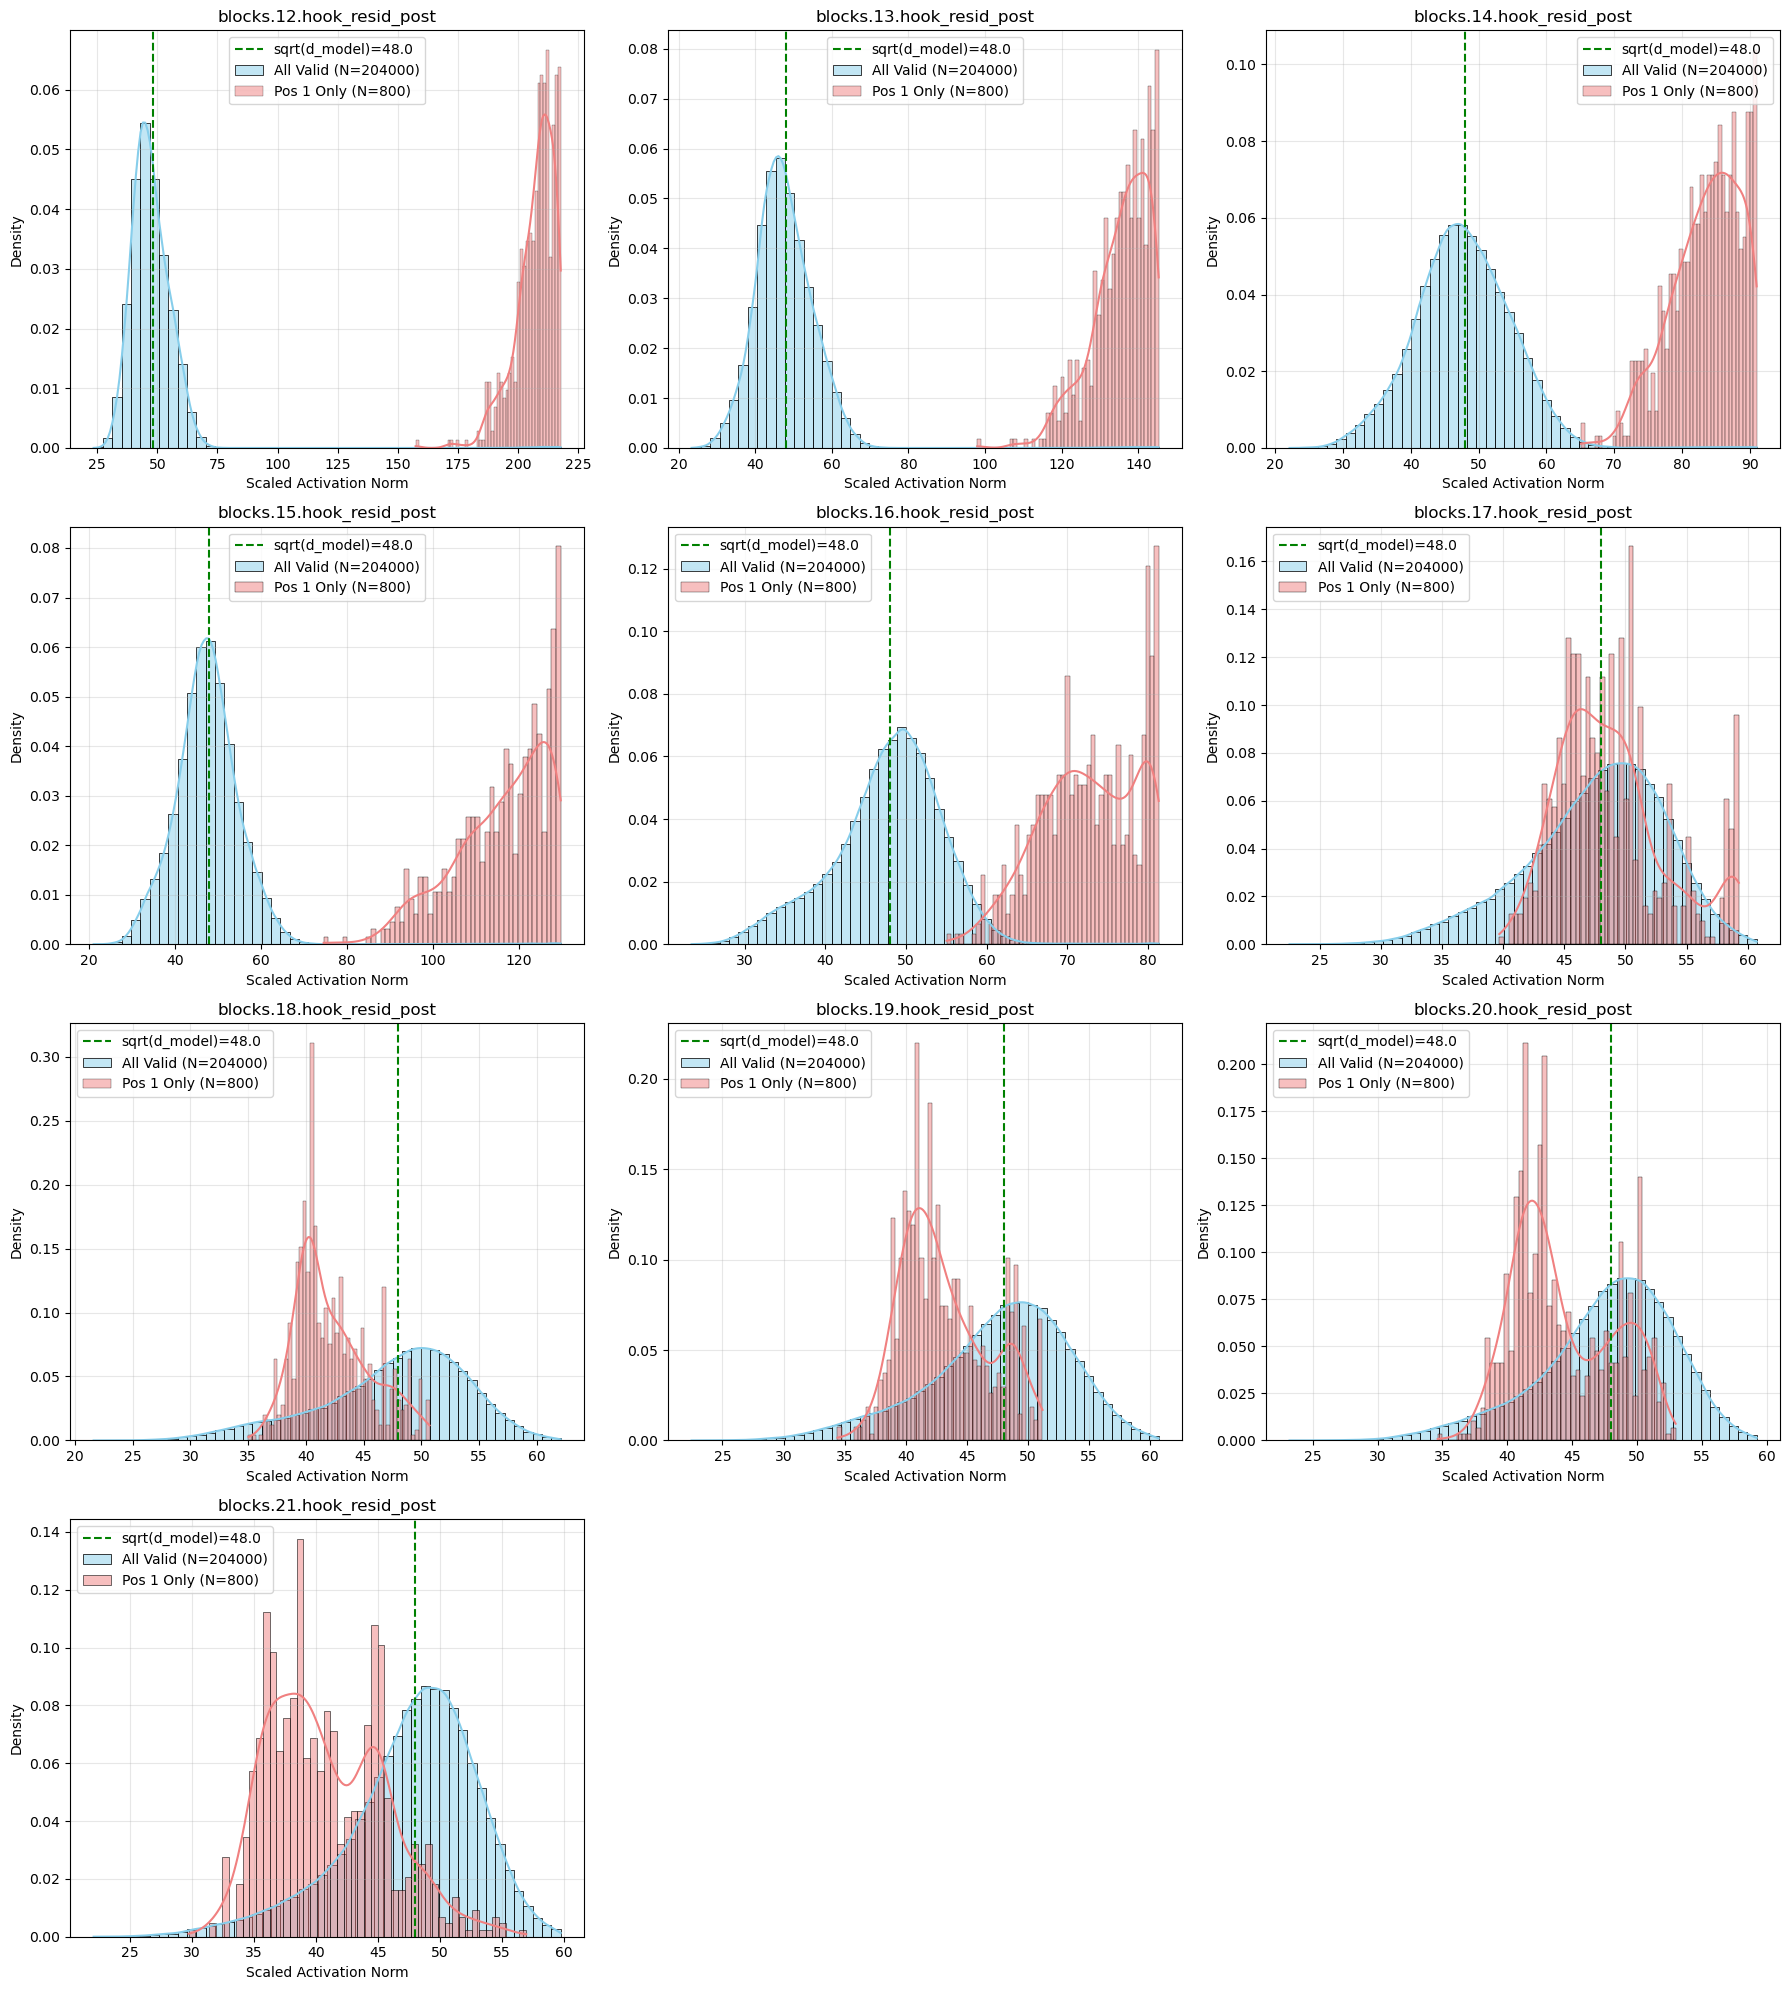

In [28]:
# %%
# Optional: Plot histograms for comparison
if PLOT_AVAILABLE:
    print("\nGenerating norm distribution plots...")
    num_hookpoints = len(TARGET_HOOKPOINTS)
    # Adjust layout based on number of hookpoints
    ncols = min(3, num_hookpoints)
    nrows = (num_hookpoints + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5), squeeze=False)
    axes = axes.flatten() # Flatten for easy iteration

    for i, hookpoint_name in enumerate(TARGET_HOOKPOINTS):
        ax = axes[i]
        pos1_norms = np.array(pos1_norms_per_hookpoint[hookpoint_name])
        all_norms = np.array(all_valid_norms_per_hookpoint[hookpoint_name])

        if len(all_norms) > 0: # Base plot on 'All Valid' having data
            # Determine a common reasonable range, clipping extreme outliers for visualization
            # Consider BOS norms too for range calculation if they exist
            plot_norms_list = [all_norms]
            if len(pos1_norms) > 0: plot_norms_list.append(pos1_norms)
            combined_norms = np.concatenate(plot_norms_list)
            upper_bound = np.percentile(combined_norms, 99.8) # Show up to 99.8th percentile

            sns.histplot(all_norms[all_norms <= upper_bound], ax=ax, color="skyblue", label=f"All Valid (N={len(all_norms)})", kde=True, stat="density", bins=50)

            if len(pos1_norms) > 0: # <<< ADDED Check
                sns.histplot(pos1_norms[pos1_norms <= upper_bound], ax=ax, color="lightcoral", label=f"Pos 1 Only (N={len(pos1_norms)})", kde=True, stat="density", bins=50)

            if len(bos_norms) > 0: # <<< ADDED Check and Plot
                sns.histplot(bos_norms[bos_norms <= upper_bound], ax=ax, color="orange", label=f"BOS Only (N={len(bos_norms)})", kde=True, stat="density", bins=50) # <<< ADDED Plot

            ax.axvline(sqrt_d_model, color='green', linestyle='--', label=f'sqrt(d_model)={sqrt_d_model:.1f}')

            ax.set_title(f"{hookpoint_name}")
            ax.set_xlabel("Scaled Activation Norm")
            ax.set_ylabel("Density")
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
             ax.set_title(f"{hookpoint_name}\n(No data for All Valid)")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("norm_distribution_by_position_and_bos.png") # <<< Updated filename
    print("Saved norm distribution plot to 'norm_distribution_by_position_and_bos.png'") # <<< Updated message
    plt.show()

### Analyzing Average Norm per Token Position

This section calculates and plots the average scaled activation norm for each position in the sequence, helping to identify if high norms are specific to position 1 or extend further.

In [33]:
# Configuration
NUM_BATCHES_TO_ANALYZE_POS = 5 # Use the same number of batches as before or adjust
TARGET_HOOKPOINTS_POS = cfg.hookpoints # Analyze the same hookpoints
MODEL_INDEX_POS = 0 # Analyze the same model
SEQUENCE_LENGTH = cfg.data.token_sequence_loader.sequence_length
INCLUDE_BOS_IN_PLOT = False # Set to False to exclude position 0

# Storage: Dictionary[hookpoint_name] -> Dictionary[position_index] -> List[norm]
norms_by_position_per_hookpoint = {
    hp: {pos: [] for pos in range(SEQUENCE_LENGTH)} for hp in TARGET_HOOKPOINTS_POS
}

print(f"Analyzing {NUM_BATCHES_TO_ANALYZE_POS} batches for position-wise norms...")
print(f"Sequence Length: {SEQUENCE_LENGTH}")

# Re-use components from previous analysis setup if needed, otherwise re-initialize
# Assuming token_sequence_loader, activations_harvester, scaling_factors_P, device, etc.
# are still available from the previous cells. If not, re-run the setup cells.
token_iter_pos = dataloader._token_sequence_loader.get_sequences_batch_iterator() # Fresh iterator

Analyzing 5 batches for position-wise norms...
Sequence Length: 256


In [34]:
# Process batches to collect norms by position
processed_batches_pos = 0
while processed_batches_pos < NUM_BATCHES_TO_ANALYZE_POS:
    try:
        print(f"Processing batch {processed_batches_pos + 1}/{NUM_BATCHES_TO_ANALYZE_POS} for position analysis...")
        # 1. Get token batch
        token_batch = next(token_iter_pos)
        tokens_HS = token_batch.tokens_HS.to(device)
        H, S = tokens_HS.shape
        if S != SEQUENCE_LENGTH:
             print(f"Warning: Skipping batch with unexpected sequence length {S}")
             continue

        # 2. Get UNFILTERED activations
        activations_HSMPD = activations_harvester.get_activations_HSMPD(tokens_HS)
        activations_HSPD = activations_HSMPD[:, :, MODEL_INDEX_POS, :, :] # Select model

        # 3. Flatten
        activations_HsPD = rearrange(activations_HSPD, "h s p d -> (h s) p d")
        positions_HS = torch.arange(S, device=device).repeat(H, 1)
        positions_Hs = rearrange(positions_HS, "h s -> (h s)")

        # 4. Scale
        scaled_activations_HsPD = activations_HsPD * scaling_factors_P.view(1, -1, 1)

        # 5. Calculate Norms
        norms_HsP = torch.norm(scaled_activations_HsPD, p=2, dim=-1) # Shape: (Hs, P)

        # 6. Store norms by position for each hookpoint
        for p_idx, hookpoint_name in enumerate(TARGET_HOOKPOINTS_POS):
            norms_Hs_hookpoint = norms_HsP[:, p_idx] # Norms for this hookpoint (Hs,)
            
            for pos in range(SEQUENCE_LENGTH):
                # Create mask for the current position
                pos_mask_Hs = (positions_Hs == pos)
                
                # Extract norms at this position
                norms_at_pos = norms_Hs_hookpoint[pos_mask_Hs].cpu().numpy()
                
                # Append to the storage dictionary
                norms_by_position_per_hookpoint[hookpoint_name][pos].extend(norms_at_pos)

        processed_batches_pos += 1

    except StopIteration:
        print("Token iterator exhausted.")
        break

Processing batch 1/5 for position analysis...
Processing batch 2/5 for position analysis...
Processing batch 3/5 for position analysis...
Processing batch 4/5 for position analysis...
Processing batch 5/5 for position analysis...


In [35]:
# Calculate average and std dev per position
position_stats_per_hookpoint = {hp: [] for hp in TARGET_HOOKPOINTS_POS}
print("\nCalculating position-wise statistics...")

for hookpoint_name, norms_by_pos in norms_by_position_per_hookpoint.items():
    for pos in range(SEQUENCE_LENGTH):
        norms_list = norms_by_pos[pos]
        if len(norms_list) > 0:
            avg_norm = np.mean(norms_list)
            std_norm = np.std(norms_list)
            count = len(norms_list)
            position_stats_per_hookpoint[hookpoint_name].append({
                "position": pos,
                "avg_norm": avg_norm,
                "std_norm": std_norm,
                "count": count
            })
        # else: # Optionally handle positions with no data
        #     position_stats_per_hookpoint[hookpoint_name].append({
        #         "position": pos, "avg_norm": np.nan, "std_norm": np.nan, "count": 0
        #     })

    # Convert list of dicts to DataFrame for easier plotting
    position_stats_per_hookpoint[hookpoint_name] = pd.DataFrame(position_stats_per_hookpoint[hookpoint_name])


Calculating position-wise statistics...


Generating average norm per position plots...
Saved average norm per position plot to 'avg_norm_per_position.png'


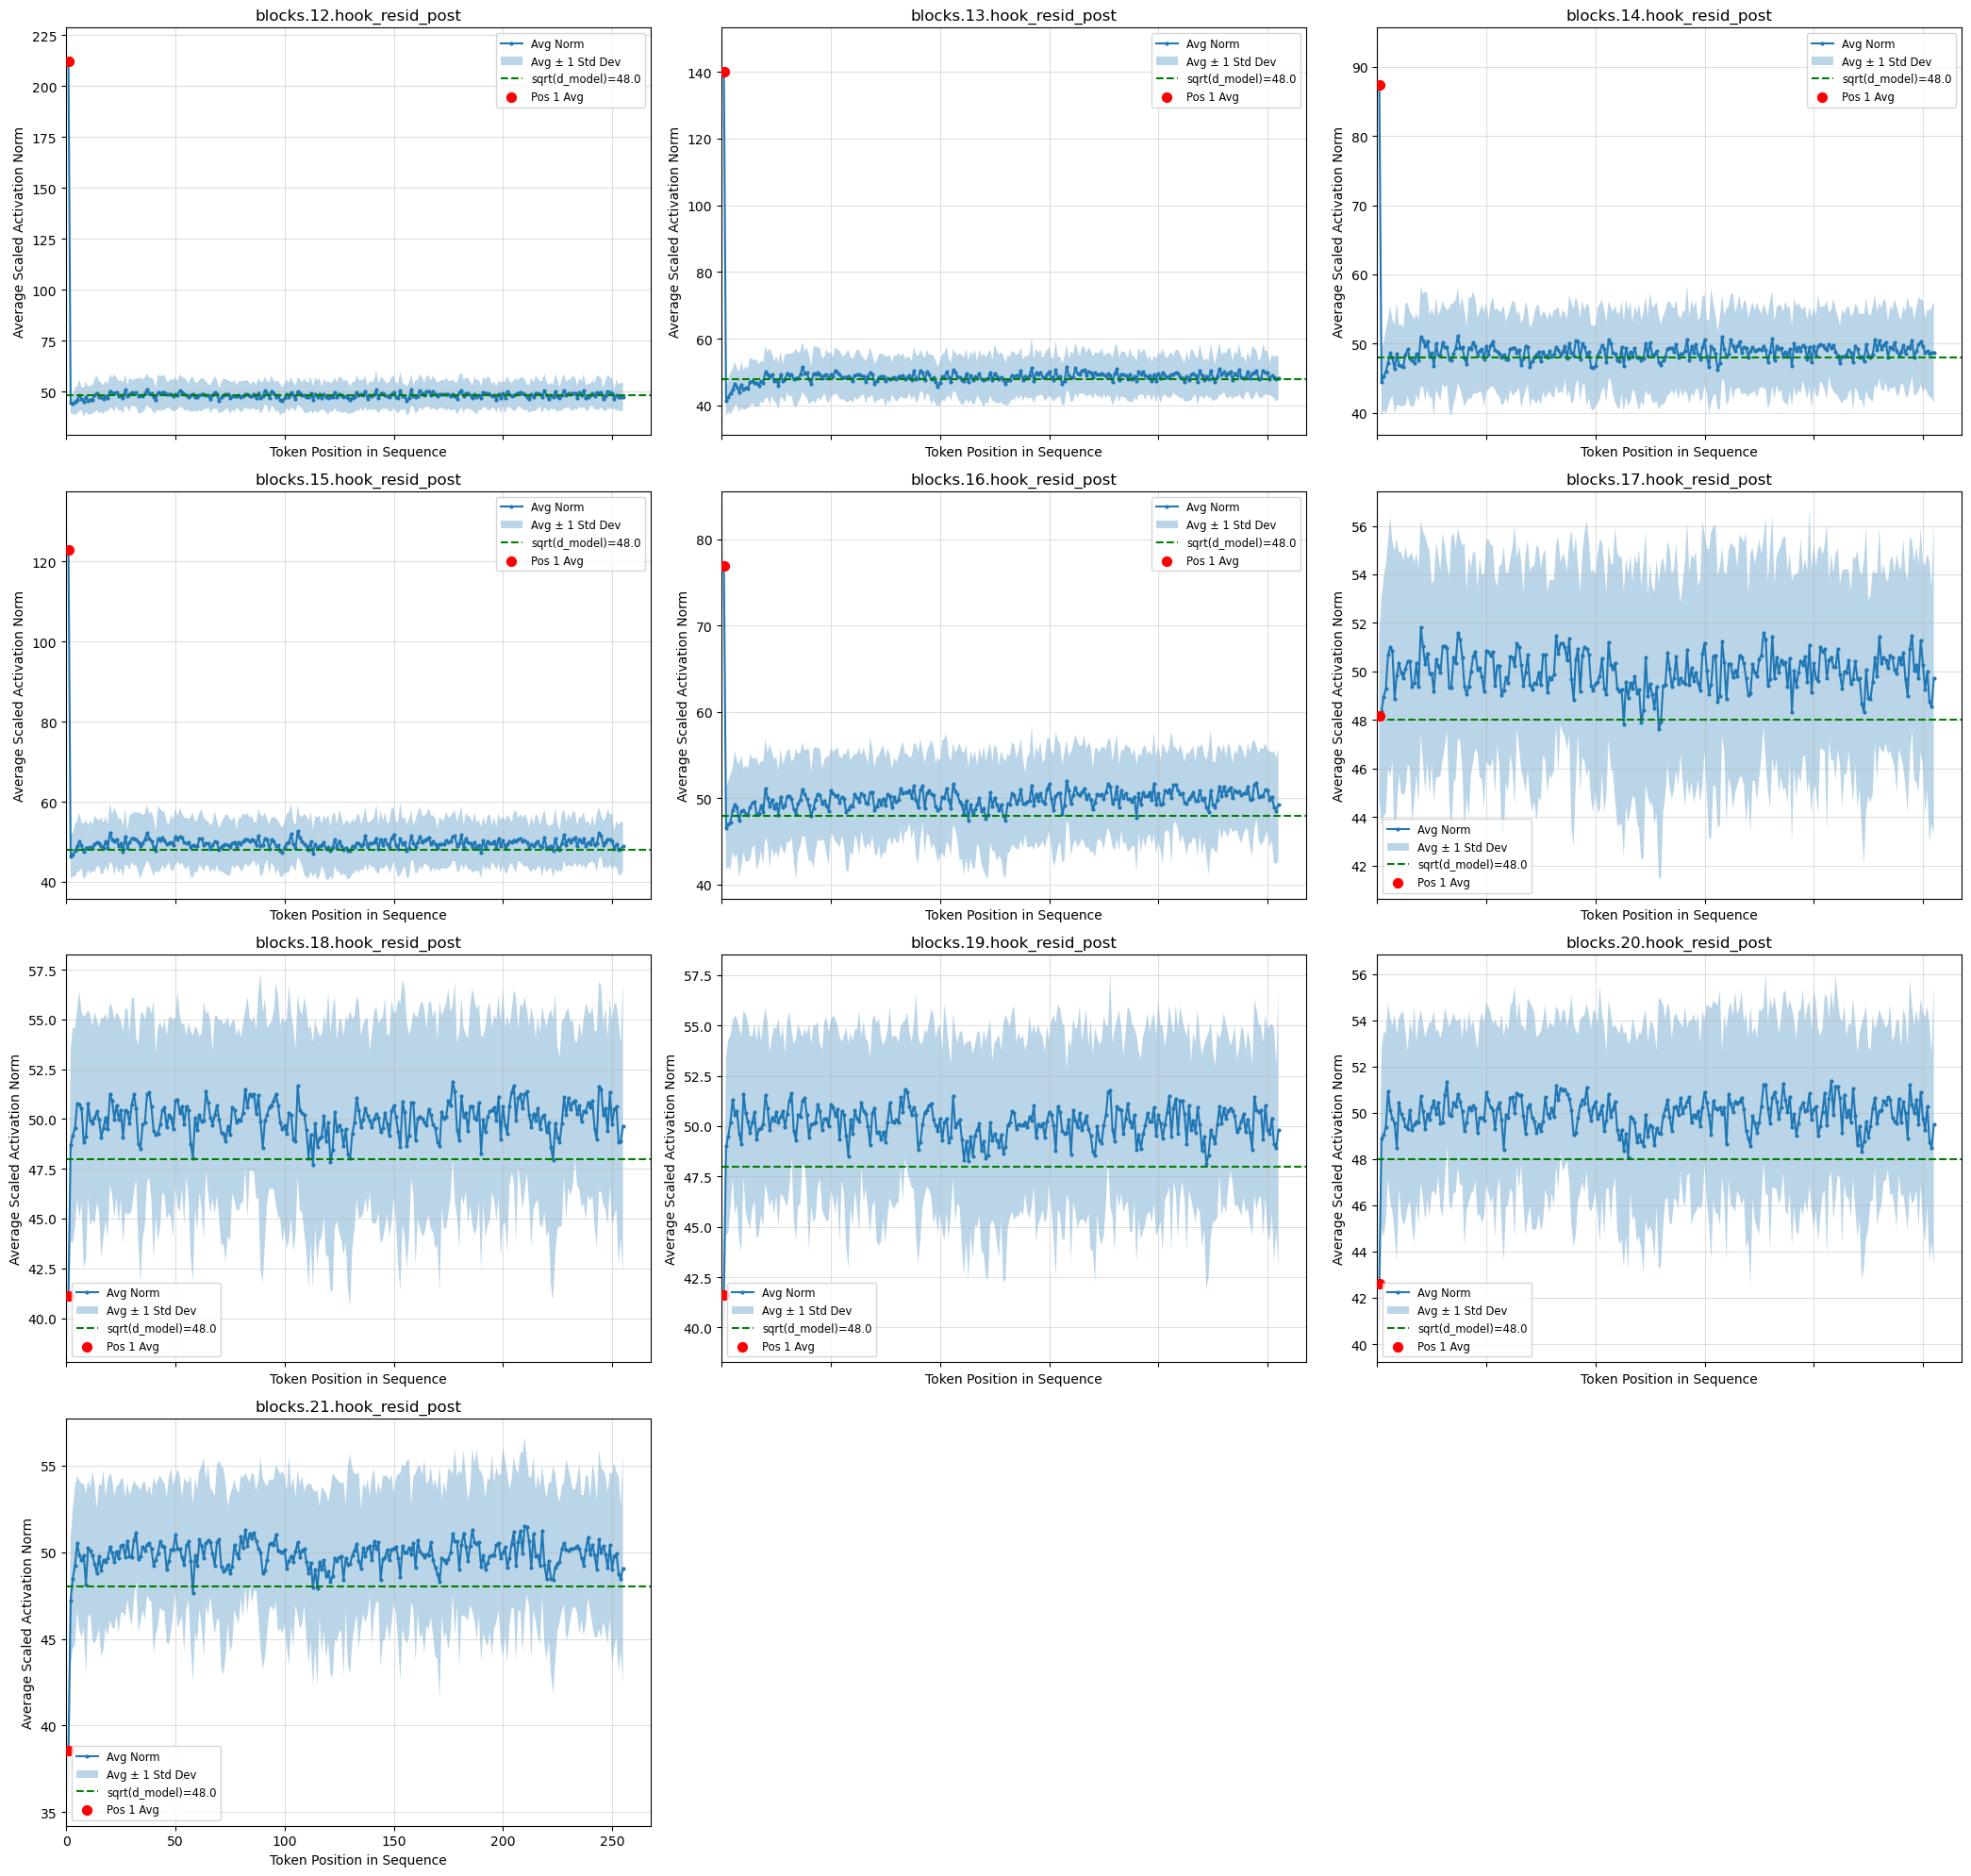


Sample Statistics (First 5 positions):

--- blocks.12.hook_resid_post ---
 position   avg_norm  std_norm  count
        0 631.559998      0.00     40
        1 212.050003      7.64     40
        2  44.320000      4.84     40
        3  43.889999      4.94     40
        4  45.060001      6.67     40

--- blocks.13.hook_resid_post ---
 position   avg_norm  std_norm  count
        0 588.849976      0.00     40
        1 140.169998      7.52     40
        2  41.430000      4.71     40
        3  42.540001      4.49     40
        4  43.669998      6.20     40


In [36]:
# Plotting the results
if PLOT_AVAILABLE:
    print("Generating average norm per position plots...")
    num_hookpoints = len(TARGET_HOOKPOINTS_POS)
    ncols = min(3, num_hookpoints)
    nrows = (num_hookpoints + ncols - 1) // ncols
    sqrt_d_model = np.sqrt(d_model)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * 5), sharex=True, squeeze=False)
    axes = axes.flatten()

    for i, hookpoint_name in enumerate(TARGET_HOOKPOINTS_POS):
        ax = axes[i]
        stats_df = position_stats_per_hookpoint[hookpoint_name]

        if not stats_df.empty:
            # Filter BOS if requested
            plot_df = stats_df if INCLUDE_BOS_IN_PLOT else stats_df[stats_df["position"] > 0]

            # Plot the average line
            ax.plot(plot_df["position"], plot_df["avg_norm"], label="Avg Norm", marker='.', linestyle='-', markersize=4)

            # Plot the standard deviation range
            ax.fill_between(
                plot_df["position"],
                plot_df["avg_norm"] - plot_df["std_norm"],
                plot_df["avg_norm"] + plot_df["std_norm"],
                alpha=0.3,
                label="Avg ± 1 Std Dev"
            )

            # Add sqrt(d_model) line
            ax.axhline(sqrt_d_model, color='green', linestyle='--', label=f'sqrt(d_model)={sqrt_d_model:.1f}')

            # Highlight position 1 specifically
            pos1_data = plot_df[plot_df["position"] == 1]
            if not pos1_data.empty:
                 ax.scatter(pos1_data["position"], pos1_data["avg_norm"], color='red', s=50, zorder=5, label="Pos 1 Avg")


            ax.set_title(f"{hookpoint_name}")
            ax.set_xlabel("Token Position in Sequence")
            ax.set_ylabel("Average Scaled Activation Norm")
            ax.legend(fontsize='small')
            ax.grid(True, alpha=0.4)
            ax.set_xlim(left=-1 if INCLUDE_BOS_IN_PLOT else 0) # Adjust x-axis start
        else:
            ax.set_title(f"{hookpoint_name}\n(No data)")


    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("avg_norm_per_position.png")
    print("Saved average norm per position plot to 'avg_norm_per_position.png'")
    plt.show()
else:
    print("Plotting skipped as Matplotlib is not available.")

# Display some raw stats as well
print("\nSample Statistics (First 5 positions):")
for hookpoint_name in TARGET_HOOKPOINTS_POS[:min(len(TARGET_HOOKPOINTS_POS), 2)]: # Show for first two hookpoints
     stats_df = position_stats_per_hookpoint[hookpoint_name]
     if not stats_df.empty:
         print(f"\n--- {hookpoint_name} ---")
         print(stats_df.head().round(2).to_string(index=False))

## Analyzing the token sequence loader

In [10]:
# Section 1: Analyze the Token Sequence Loader
# ---------------------------------------------
print("=== TOKEN SEQUENCE LOADER ANALYSIS ===")

# Extract the token sequence loader from the dataloader
token_sequence_loader = dataloader._token_sequence_loader
tokenizer = llms[0].tokenizer

print(f"Dataset name: {cfg.data.token_sequence_loader.hf_dataset_name}")
print(f"Sequence length: {cfg.data.token_sequence_loader.sequence_length}")
print(f"Harvesting batch size: {cfg.data.activations_harvester.harvesting_batch_size}")
print(f"Model: {cfg.data.activations_harvester.llms[0].name}")

# Get the special tokens
special_tokens = tokenizer.all_special_tokens
special_ids = tokenizer.all_special_ids
print(f"\nSpecial tokens: {special_tokens}")
print(f"Special token IDs: {special_ids}")

=== TOKEN SEQUENCE LOADER ANALYSIS ===
Dataset name: HuggingFaceFW/fineweb
Sequence length: 256
Harvesting batch size: 8
Model: google/gemma-2-2b

Special tokens: ['<bos>', '<eos>', '<unk>', '<pad>', '<start_of_turn>', '<end_of_turn>']
Special token IDs: [2, 1, 3, 0, 106, 107]


In [11]:
# Allow specifying a range of training steps to analyze
def get_sequence_batches_for_training_steps(start_step, end_step):
    # Create a fresh TokenSequenceLoader with the same parameters
    fresh_loader = TokenSequenceLoader.from_hf_dataset_name(
        hf_dataset_name=cfg.data.token_sequence_loader.hf_dataset_name,
        sequence_length=cfg.data.token_sequence_loader.sequence_length,
        cache_dir=cfg.cache_dir,
        tokenizer=llms[0].tokenizer,
        batch_size=cfg.data.activations_harvester.harvesting_batch_size,
        shuffle_buffer_size=None  # Disable shuffling for deterministic output
    )
    
    # Simulate the token consumption used for scaling factor estimation
    n_tokens_for_norm_estimate = cfg.data.n_tokens_for_norm_estimate
    
    # Calculate how many sequence batches would be consumed during estimation
    tokens_per_sequence = cfg.data.token_sequence_loader.sequence_length  # 512 in your case
    estimated_special_token_ratio = 0.01  # Rough estimate
    non_special_tokens_per_sequence = tokens_per_sequence * (1 - estimated_special_token_ratio)
    
    # Adjust for harvesting batch size (usually 1)
    non_special_tokens_per_batch = non_special_tokens_per_sequence * cfg.data.activations_harvester.harvesting_batch_size
    
    # Calculate sequences needed for norm estimation
    sequences_for_norm_estimate = int(n_tokens_for_norm_estimate / non_special_tokens_per_batch) + 1
    
    print(f"Simulating consumption of {sequences_for_norm_estimate} sequences for norm estimation")
    
    # Skip these sequences to simulate depletion
    sequence_iterator = fresh_loader.get_sequences_batch_iterator()
    for i in range(sequences_for_norm_estimate):
        try:
            next(sequence_iterator)
        except StopIteration:
            print(f"Warning: Dataset exhausted after {i} sequences during norm estimation simulation")
            return []
    
    # Now calculate which sequence batches we need for the specified training steps
    # Each training batch has 128 tokens after filtering special tokens
    training_batch_size = cfg.train.batch_size  # 128 in your case
    
    # How many raw tokens we need per training batch
    raw_tokens_per_training_batch = training_batch_size / (1 - estimated_special_token_ratio)
    
    # How many sequences per training batch
    sequences_per_training_batch = raw_tokens_per_training_batch / tokens_per_sequence
    
    # Start and end sequence indices (with some margin)
    start_sequence = int(start_step * sequences_per_training_batch)
    end_sequence = int(end_step * sequences_per_training_batch) + 1
    
    print(f"Fetching sequences from index {start_sequence} to {end_sequence} (after norm estimation)")
    print(f"This should approximately cover training steps {start_step} to {end_step}")
    
    # Skip to start position
    for i in range(start_sequence):
        try:
            next(sequence_iterator)
        except StopIteration:
            print(f"Warning: Dataset exhausted after {i} sequences")
            return []
    
    # Collect requested sequences
    sequences = []
    for i in range(end_sequence - start_sequence):
        try:
            sequences.append(next(sequence_iterator))
        except StopIteration:
            print(f"Warning: Dataset exhausted after fetching {len(sequences)} sequences")
            break
    
    return sequences

In [12]:
# Specify which training steps to analyze
start_training_step = 0
end_training_step = 10

sequences = get_sequence_batches_for_training_steps(start_training_step, end_training_step)
print(f"Retrieved {len(sequences)} sequence batches")

Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

Simulating consumption of 50 sequences for norm estimation
Fetching sequences from index 0 to 41 (after norm estimation)
This should approximately cover training steps 0 to 10
Retrieved 41 sequence batches


In [13]:
# Section 3: Analyze the Sequences in Detail
# -----------------------------------------
print("\n=== SEQUENCE DETAIL ANALYSIS ===")

# Number of chunks to show from the beginning and end of each sequence
NUM_CHUNKS_TO_SHOW = 2  # Show first 2 and last 2 chunks
CHUNK_SIZE = 50  # 50 tokens per chunk

for i, seq_batch in enumerate(sequences):
    print(f"\nSequence Batch {i+1}:")
    print(f"Shape: {seq_batch.tokens_HS.shape}")
    
    # Count special tokens
    special_mask = seq_batch.special_tokens_mask_HS
    special_count = special_mask.sum().item()
    print(f"Number of special tokens: {special_count} ({special_count/special_mask.numel()*100:.2f}%)")
    
    # Get the tokens from the first sequence in the batch
    tokens = seq_batch.tokens_HS[0]
    token_texts = tokenizer.convert_ids_to_tokens(tokens.tolist())
    
    # Find document boundaries (BOS tokens)
    bos_positions = [j for j, token_id in enumerate(tokens.tolist()) if token_id == tokenizer.bos_token_id]
    print(f"Document boundaries (BOS positions): {bos_positions}")
    
    # Print first 10 tokens of each subsequence
    print("\nFirst 10 tokens of each document:")
    for pos in bos_positions[:5]:  # Limit to first 5 documents for clarity
        end = min(pos + 10, len(token_texts))
        document_start = token_texts[pos:end]
        print(f"  Position {pos}: {document_start}")
    
    # Print beginning and end chunks of the sequence
    print("\nFirst and last chunks of the full sequence:")
    total_chunks = (len(token_texts) + CHUNK_SIZE - 1) // CHUNK_SIZE  # Ceiling division
    
    # Print first N chunks
    for j in range(min(NUM_CHUNKS_TO_SHOW, total_chunks)):
        start_idx = j * CHUNK_SIZE
        end_idx = min(start_idx + CHUNK_SIZE, len(token_texts))
        chunk = token_texts[start_idx:end_idx]
        
        # Highlight any BOS tokens for clarity
        highlighted_chunk = []
        for token in chunk:
            if token == tokenizer.bos_token:
                highlighted_chunk.append(f"**{token}**")
            else:
                highlighted_chunk.append(token)
        
        print(f"  Tokens {start_idx}-{end_idx-1}: {highlighted_chunk}")
    
    # If there are more chunks in the middle, show ellipsis
    if total_chunks > 2 * NUM_CHUNKS_TO_SHOW:
        print("  ...")
    
    # Print last N chunks (unless they overlap with first N)
    for j in range(max(NUM_CHUNKS_TO_SHOW, total_chunks - NUM_CHUNKS_TO_SHOW), total_chunks):
        start_idx = j * CHUNK_SIZE
        end_idx = min(start_idx + CHUNK_SIZE, len(token_texts))
        chunk = token_texts[start_idx:end_idx]
        
        # Highlight any BOS tokens for clarity
        highlighted_chunk = []
        for token in chunk:
            if token == tokenizer.bos_token:
                highlighted_chunk.append(f"**{token}**")
            else:
                highlighted_chunk.append(token)
        
        print(f"  Tokens {start_idx}-{end_idx-1}: {highlighted_chunk}")
    


=== SEQUENCE DETAIL ANALYSIS ===

Sequence Batch 1:
Shape: torch.Size([8, 256])
Number of special tokens: 8 (0.39%)
Document boundaries (BOS positions): [0]

First 10 tokens of each document:
  Position 0: ['<bos>', '▁and', '▁have', '▁stopped', '▁trying', '.', '▁What', '▁is', '▁more', ',']

First and last chunks of the full sequence:
  Tokens 0-49: ['**<bos>**', '▁and', '▁have', '▁stopped', '▁trying', '.', '▁What', '▁is', '▁more', ',', '▁there', '▁are', '▁too', '▁many', '▁other', '▁Christians', '▁out', '▁there', '▁all', '▁too', '▁ready', '▁to', '▁remind', '▁them', '▁of', '▁the', '▁mark', '.', '▁Though', '▁life', '▁has', '▁moved', '▁on', ',', '▁they', '▁continue', '▁to', '▁point', '▁their', '▁finger', '▁into', '▁the', '▁past', '▁-', '▁"', 'Failure', '"', '▁is', '▁on', '▁their']
  Tokens 50-99: ['▁lips', '▁every', '▁time', '▁they', '▁say', '▁hello', ',', '▁and', '▁the', '▁engraving', '▁grows', '▁a', '▁little', '▁deeper', '.', '\n', 'We', '▁do', '▁not', '▁have', '▁to', '▁live', '▁the', '

As we can see there are no document breaks across 3 sequences of 512 tokens. How long are these documents on average?

## Analyzing the HF dataset

In [14]:
import numpy as np
import random

In [17]:
def analyze_hf_dataset_documents(num_documents=100, seed=42):
    """Analyze a sample of documents from the Hugging Face dataset"""
    # Set seeds for deterministic behavior
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # Load dataset directly
    from datasets import load_dataset
    
    print(f"Loading dataset: {cfg.data.token_sequence_loader.hf_dataset_name}")
    dataset = load_dataset(
        path=cfg.data.token_sequence_loader.hf_dataset_name,
        streaming=True,
        cache_dir=cfg.cache_dir,
        split="train",
    )
    
    # Sample documents and analyze lengths
    document_lengths = []
    token_lengths = []
    tokenizer = llms[0].tokenizer
    
    print(f"Analyzing {num_documents} documents...")
    for i, example in enumerate(dataset):
        if i >= num_documents:
            break
            
        text = example["text"]
        tokens = tokenizer(text, return_tensors="pt")["input_ids"].squeeze(0)
        
        document_lengths.append(len(text))
        token_lengths.append(len(tokens))
        
        if i == 0:
            # Display the first document for inspection
            preview_len = min(200, len(text))
            print(f"\nFirst document preview (first {preview_len} chars):")
            print(f"{text[:preview_len]}...")
            
            token_preview = tokenizer.convert_ids_to_tokens(tokens[:20].tolist())
            print(f"First 20 tokens: {token_preview}")
    
    # Calculate statistics
    avg_doc_length = sum(document_lengths) / len(document_lengths)
    avg_token_length = sum(token_lengths) / len(token_lengths)
    
    min_doc_length = min(document_lengths)
    max_doc_length = max(document_lengths)
    
    min_token_length = min(token_lengths)
    max_token_length = max(token_lengths)
    
    # Calculate distribution statistics
    doc_quartiles = np.percentile(document_lengths, [25, 50, 75])
    token_quartiles = np.percentile(token_lengths, [25, 50, 75])
    
    # Print results
    print("\nDocument length statistics (characters):")
    print(f"  Average: {avg_doc_length:.1f}")
    print(f"  Min: {min_doc_length}")
    print(f"  Max: {max_doc_length}")
    print(f"  Quartiles (25%, 50%, 75%): {doc_quartiles[0]:.1f}, {doc_quartiles[1]:.1f}, {doc_quartiles[2]:.1f}")
    
    print("\nToken length statistics (tokens per document):")
    print(f"  Average: {avg_token_length:.1f}")
    print(f"  Min: {min_token_length}")
    print(f"  Max: {max_token_length}")
    print(f"  Quartiles (25%, 50%, 75%): {token_quartiles[0]:.1f}, {token_quartiles[1]:.1f}, {token_quartiles[2]:.1f}")
    
    # Show distribution
    bins = [0, 100, 500, 1000, 2000, 5000, 10000, float('inf')]
    bin_names = ['<100', '100-500', '500-1k', '1k-2k', '2k-5k', '5k-10k', '>10k']
    
    token_distribution = [0] * len(bin_names)
    for length in token_lengths:
        for i in range(len(bins) - 1):
            if bins[i] <= length < bins[i + 1]:
                token_distribution[i] += 1
                break
    
    print("\nToken length distribution:")
    for i, count in enumerate(token_distribution):
        percentage = (count / len(token_lengths)) * 100
        print(f"  {bin_names[i]}: {count} documents ({percentage:.1f}%)")
    
    return document_lengths, token_lengths

In [18]:
# Section 8: Analyze the HF Dataset Document Properties
# -----------------------------------------------------
print("\n=== HUGGING FACE DATASET DOCUMENT ANALYSIS ===")

# Analyze a sample of documents from the dataset
document_lengths, token_lengths = analyze_hf_dataset_documents(num_documents=1000)


=== HUGGING FACE DATASET DOCUMENT ANALYSIS ===
Loading dataset: HuggingFaceFW/fineweb


Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25868 [00:00<?, ?it/s]

Analyzing 1000 documents...

First document preview (first 200 chars):
How AP reported in all formats from tornado-stricken regionsMarch 8, 2012
When the first serious bout of tornadoes of 2012 blew through middle America in the middle of the night, they touched down in ...
First 20 tokens: ['<bos>', 'How', '▁AP', '▁reported', '▁in', '▁all', '▁formats', '▁from', '▁tornado', '-', 'stricken', '▁regions', 'March', '▁', '8', ',', '▁', '2', '0', '1']

Document length statistics (characters):
  Average: 3281.0
  Min: 217
  Max: 209976
  Quartiles (25%, 50%, 75%): 873.8, 1736.5, 3439.5

Token length statistics (tokens per document):
  Average: 748.3
  Min: 59
  Max: 46201
  Quartiles (25%, 50%, 75%): 197.8, 392.0, 781.0

Token length distribution:
  <100: 66 documents (6.6%)
  100-500: 524 documents (52.4%)
  500-1k: 226 documents (22.6%)
  1k-2k: 118 documents (11.8%)
  2k-5k: 58 documents (5.8%)
  5k-10k: 4 documents (0.4%)
  >10k: 4 documents (0.4%)


2025-04-20 07:42:53 - INFO - generated new fontManager



Histogram saved as 'document_length_distribution.png'
Note: 184 documents (18.4%) with >1000 tokens were excluded from the visualization


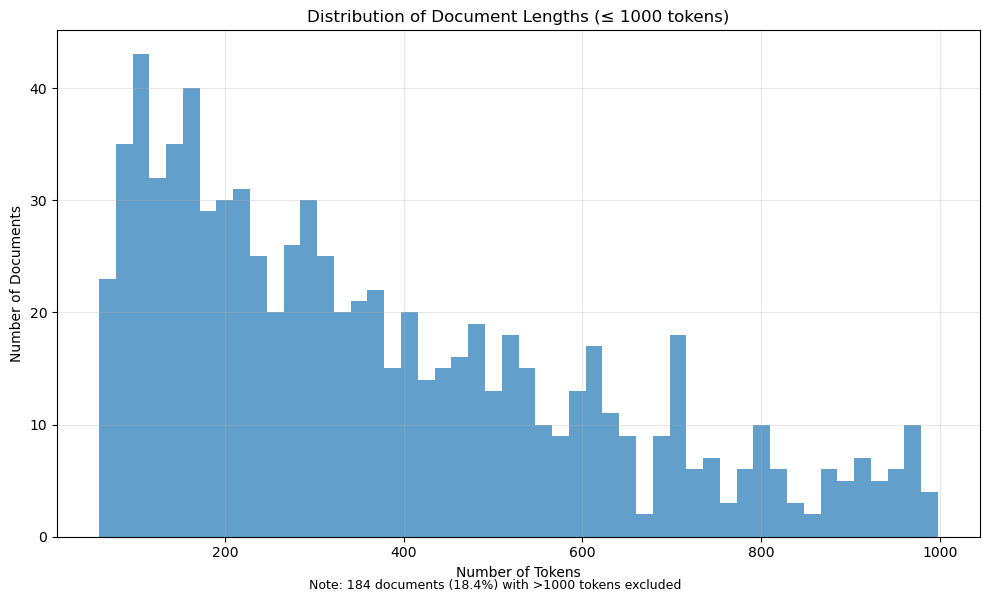

In [19]:
# Optional: If you want to visualize the distribution as a histogram
try:
    import matplotlib.pyplot as plt
    
    # Filter out documents longer than 1000 tokens for better visualization
    filtered_lengths = [length for length in token_lengths if length <= 1000]
    
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_lengths, bins=50, alpha=0.7)
    plt.title('Distribution of Document Lengths (≤ 1000 tokens)')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Number of Documents')
    plt.grid(True, alpha=0.3)
    
    # Add a note about excluded documents
    excluded_count = len(token_lengths) - len(filtered_lengths)
    excluded_percent = (excluded_count / len(token_lengths)) * 100 if token_lengths else 0
    plt.figtext(0.5, 0.01, 
                f'Note: {excluded_count} documents ({excluded_percent:.1f}%) with >1000 tokens excluded', 
                ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('document_length_distribution.png')
    print(f"\nHistogram saved as 'document_length_distribution.png'")
    print(f"Note: {excluded_count} documents ({excluded_percent:.1f}%) with >1000 tokens were excluded from the visualization")
except ImportError:
    print("\nMatplotlib not available for visualization. Install with 'pip install matplotlib'")
except Exception as e:
    print(f"\nCould not generate visualization: {e}")